# EDA — Precos de Combustiveis no DF
**Projeto:** Sistema Inteligente de Previsao de Precos
**Dados:** ANP | Periodo: 2023-2026

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

PROCESSED_DIR = Path('../..') / 'data' / 'processed'
df = pd.read_parquet(PROCESSED_DIR / 'precos_df.parquet')
df['data_coleta'] = pd.to_datetime(df['data_coleta'])
df['mes'] = df['data_coleta'].dt.month
df['ano'] = df['data_coleta'].dt.year
df['dia_semana'] = df['data_coleta'].dt.day_name()
df['semana'] = df['data_coleta'].dt.to_period('W').dt.start_time
print(f'Registros: {len(df):,}')
print(f'Periodo: {df.data_coleta.min().date()} ate {df.data_coleta.max().date()}')
print(f'Produtos: {df.produto.nunique()}')
print(f'Municipios: {df.municipio.nunique()}')
print(f'Postos: {df.cnpj.nunique()}')
df.head()

Registros: 27,213
Periodo: 2023-02-10 ate 2026-12-02
Produtos: 7
Municipios: 1
Postos: 238


,cnpj,razao_social,nome_fantasia,endereco,numero,complemento,bairro,cep,municipio,estado,bandeira,produto,unidade,preco_revenda,data_coleta,mes,ano,dia_semana,semana
0,7917405000138,BANTA COMERCIO DE COMBUSTIVEIS LTDA,POSTO GARZZO,AREA ADE CONJUNTO 23,LT 35,E 36,AREA DE DESENVOLVIMENTO ECONOMICO (AGUAS CLARAS),71990180,BRASILIA,DISTRITO FEDERAL,RAIZEN,DIESEL S10,R$ / LITRO,6.29,2023-02-10,2,2023,Friday,2023-02-06
1,306597009315,CASCOL COMBUSTIVEIS PARA VEICULOS LTDA,NAN,QUADRA QS 09 RUA 120 LOTE,28,None,AGUAS CLARAS,71977180,BRASILIA,DISTRITO FEDERAL,BRANCA,DIESEL S10,R$ / LITRO,6.25,2023-02-10,2,2023,Friday,2023-02-06
2,306597005590,CASCOL COMBUSTIVEIS PARA VEICULOS LTDA,NAN,SEGUNDA AVENIDA SEGUNDA AV. NORTE LOTE,45211,None,SAMAMBAIA,72320000,BRASILIA,DISTRITO FEDERAL,VIBRA,DIESEL S10,R$ / LITRO,6.31,2023-02-10,2,2023,Friday,2023-02-06
3,306597008777,CASCOL COMBUSTIVEIS PARA VEICULOS LTDA,NAN,QUADRA QN 122 CONJUNTO 07 LOTE,6,None,SAMAMBAIA,72310108,BRASILIA,DISTRITO FEDERAL,IPIRANGA,DIESEL S10,R$ / LITRO,6.30,2023-02-10,2,2023,Friday,2023-02-06
4,306597006804,CASCOL COMBUSTIVEIS PARA VEICULOS LTDA,NAN,QUADRA QSE AREA ESPECIAL PARA POSTO DE COMBUST...,S/N,None,TAGUATINGA,72025001,BRASILIA,DISTRITO FEDERAL,BRANCA,DIESEL S10,R$ / LITRO,6.15,2023-02-10,2,2023,Friday,2023-02-06


## 1. Visao Geral dos Dados

In [3]:
print('=== Informacoes Gerais ===')
print(df.dtypes)
print()
print('=== Valores Nulos ===')
print(df.isnull().sum())
print()
print('=== Estatisticas Descritivas ===')
df.groupby('produto')['preco_revenda'].describe().round(2)

=== Informacoes Gerais ===
cnpj                     object
razao_social             object
nome_fantasia            object
endereco                 object
numero                   object
complemento              object
bairro                   object
cep                      object
municipio                object
estado                   object
bandeira                 object
produto                  object
unidade                  object
preco_revenda           float64
data_coleta      datetime64[ns]
mes                       int32
ano                       int32
dia_semana               object
semana           datetime64[ns]
dtype: object

=== Valores Nulos ===
cnpj                 0
razao_social         0
nome_fantasia        0
endereco             0
numero             153
complemento      19418
bairro               0
cep                  0
municipio            0
estado               0
bandeira             0
produto              0
unidade              0
preco_revenda        0
data_c

,count,mean,std,min,25%,50%,75%,max
produto,,,,,,,,
DIESEL S10,2786.0,5.94,0.40,4.68,5.81,5.98,6.19,6.99
DIESEL S500,2638.0,5.89,0.41,4.65,5.77,5.95,6.13,7.02
ETANOL,4158.0,4.09,0.47,3.28,3.69,3.99,4.50,5.27
GASOLINA ADITIVADA,5736.0,6.09,0.41,4.99,5.79,6.08,6.48,7.29
GASOLINA COMUM,6391.0,6.03,0.42,4.95,5.69,5.99,6.46,6.89
GLP,5487.0,98.18,6.72,77.99,94.99,97.99,101.99,120.00
GNV,17.0,6.57,0.25,6.04,6.69,6.69,6.69,6.69


## 2. Evolucao de Preco ao Longo do Tempo

In [4]:
produtos_principais = ['GASOLINA COMUM', 'ETANOL', 'DIESEL S10']
df_plot = df[df['produto'].isin(produtos_principais)]
preco_semanal = df_plot.groupby(['semana', 'produto'])['preco_revenda'].mean().reset_index()

fig = px.line(
    preco_semanal,
    x='semana', y='preco_revenda', color='produto',
    title='Evolucao Semanal do Preco Medio — DF',
    labels={'preco_revenda': 'Preco Medio (R$)', 'semana': 'Data', 'produto': 'Produto'},
    template='plotly_white'
)
fig.update_layout(hovermode='x unified')
fig.show()

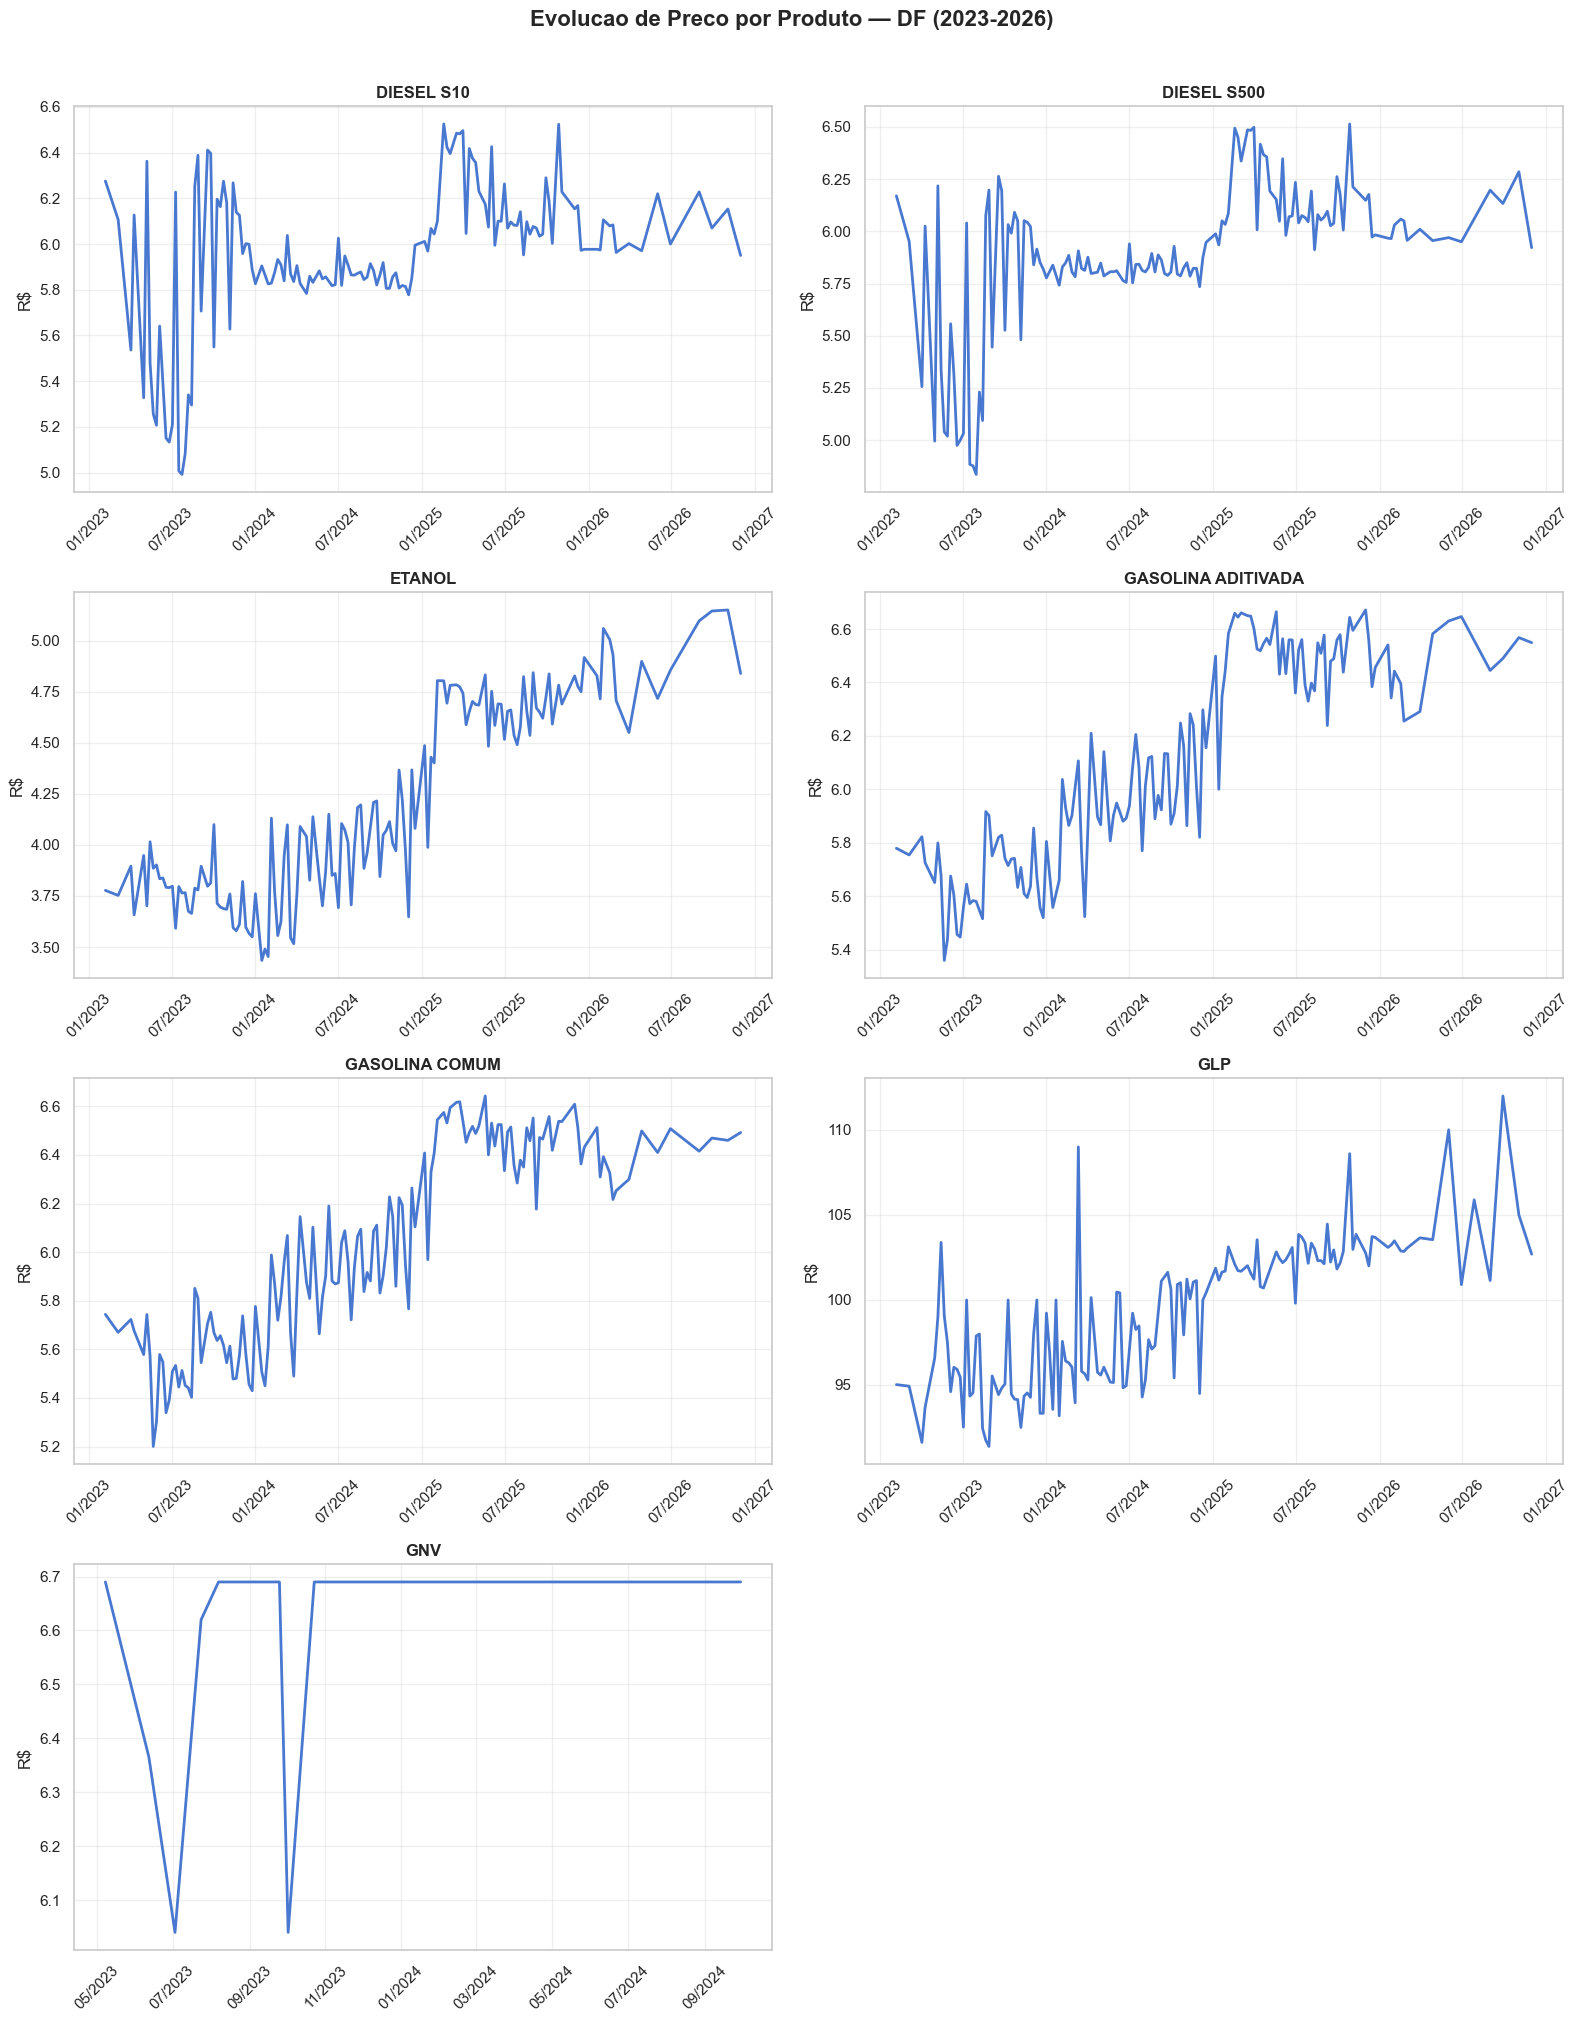

In [5]:
# Todos os produtos
preco_semanal_all = df.groupby(['semana', 'produto'])['preco_revenda'].mean().reset_index()

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, produto in enumerate(sorted(df['produto'].unique())):
    data = preco_semanal_all[preco_semanal_all['produto'] == produto]
    axes[i].plot(data['semana'], data['preco_revenda'], linewidth=2)
    axes[i].set_title(produto, fontweight='bold')
    axes[i].set_ylabel('R$')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

# Esconde subplot vazio se tiver numero impar de produtos
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Evolucao de Preco por Produto — DF (2023-2026)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../../data/processed/evolucao_precos.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Comparacao entre Produtos

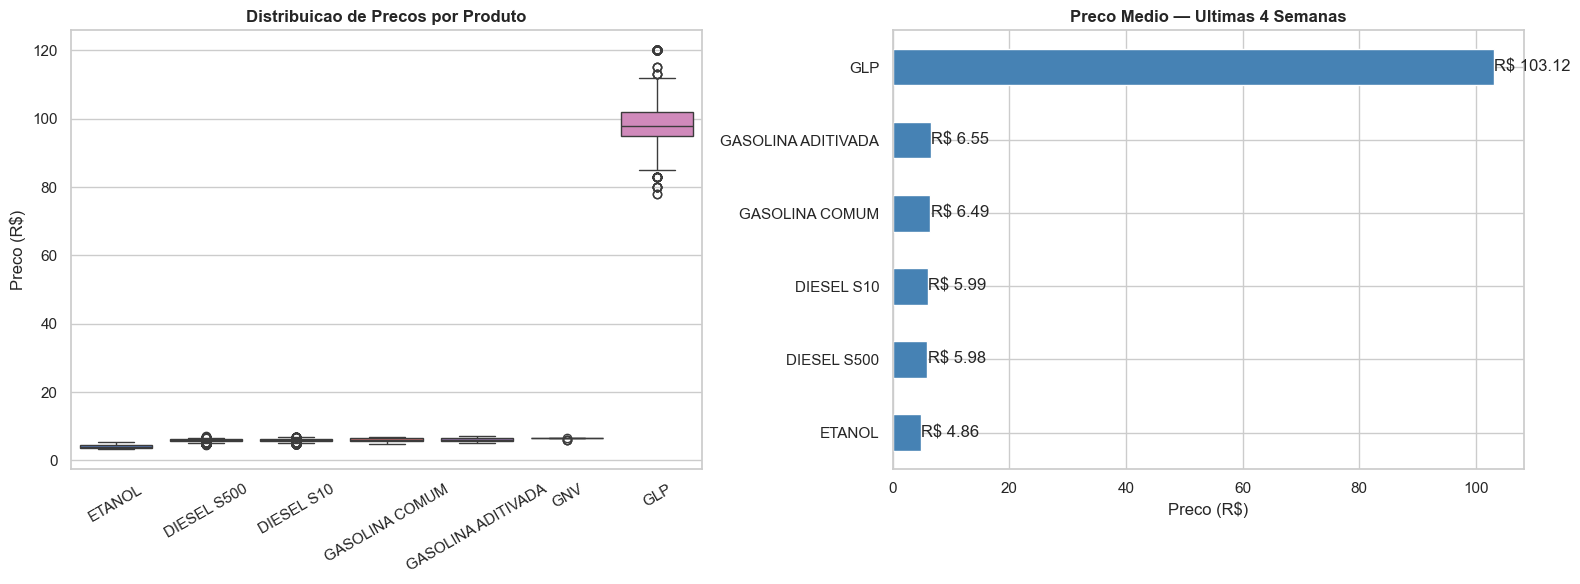

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
ordem = df.groupby('produto')['preco_revenda'].median().sort_values().index
sns.boxplot(data=df, x='produto', y='preco_revenda', order=ordem, ax=axes[0], palette='muted')
axes[0].set_title('Distribuicao de Precos por Produto', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Preco (R$)')
axes[0].tick_params(axis='x', rotation=30)

# Preco medio atual (ultimas 4 semanas)
ultima_data = df['semana'].max()
df_recente = df[df['semana'] >= ultima_data - pd.Timedelta(weeks=4)]
preco_atual = df_recente.groupby('produto')['preco_revenda'].mean().sort_values()
preco_atual.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Preco Medio — Ultimas 4 Semanas', fontweight='bold')
axes[1].set_xlabel('Preco (R$)')
axes[1].set_ylabel('')
for i, v in enumerate(preco_atual):
    axes[1].text(v + 0.02, i, f'R$ {v:.2f}', va='center')

plt.tight_layout()
plt.show()

## 4. Variacao por Regiao do DF

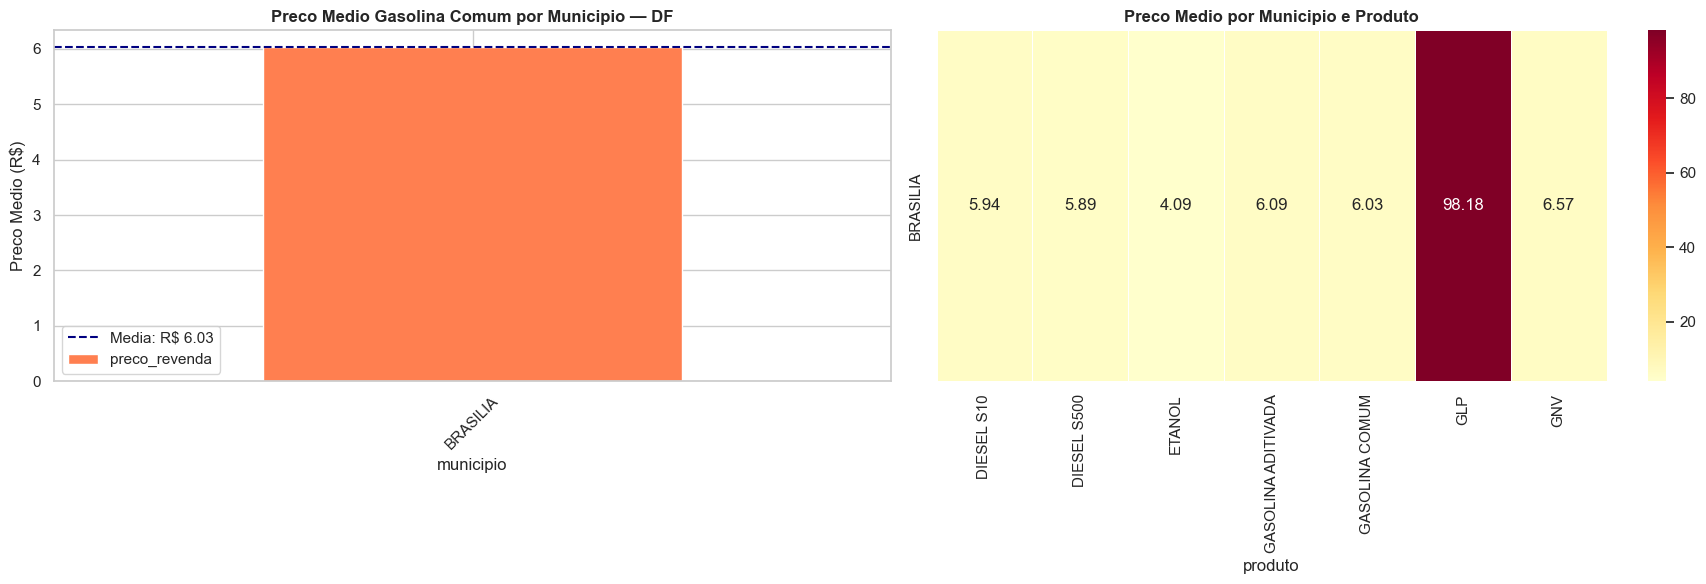

In [ ]:
# Top municipios por volume de registros
top_municipios = df['municipio'].value_counts().head(15).index
df_mun = df[df['municipio'].isin(top_municipios)]

# Preco medio por municipio e produto
preco_mun = df_mun[df_mun['produto'] == 'GASOLINA COMUM'].groupby('bairro')['preco_revenda'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Barplot por municipio
preco_mun.plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Preco Medio Gasolina Comum por Municipio — DF', fontweight='bold')
axes[0].set_ylabel('Preco Medio (R$)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(preco_mun.mean(), color='navy', linestyle='--', label=f'Media: R$ {preco_mun.mean():.2f}')
axes[0].legend()

# Heatmap municipio x produto
heatmap_data = df_mun.groupby(['bairro', 'produto'])['preco_revenda'].mean().unstack()
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1], linewidths=0.5)
axes[1].set_title('Preco Medio por Municipio e Produto', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 5. Postos Mais Caros vs Mais Baratos

In [ ]:
produto_analise = 'GASOLINA COMUM'
df_gas = df[df['produto'] == produto_analise]

preco_posto = df_gas.groupby(['cnpj', 'nome_fantasia', 'municipio', 'bandeira'])['preco_revenda'].agg(['mean', 'count']).reset_index()
preco_posto.columns = ['cnpj', 'nome', 'municipio', 'bandeira', 'preco_medio', 'n_registros']
preco_posto = preco_posto[preco_posto['n_registros'] >= 5].sort_values('preco_medio')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 10 mais baratos
top_baratos = preco_posto.head(10)
label_b = top_baratos.apply(lambda r: f"{r['nome'][:20]} ({r['municipio'][:10]})", axis=1)
axes[0].barh(label_b, top_baratos['preco_medio'], color='seagreen')
axes[0].set_title(f'10 Postos Mais Baratos — {produto_analise}', fontweight='bold')
axes[0].set_xlabel('Preco Medio (R$)')
for i, v in enumerate(top_baratos['preco_medio']):
    axes[0].text(v + 0.01, i, f'R$ {v:.2f}', va='center', fontsize=9)

# 10 mais caros
top_caros = preco_posto.tail(10).sort_values('preco_medio', ascending=False)
label_c = top_caros.apply(lambda r: f"{r['nome'][:20]} ({r['municipio'][:10]})", axis=1)
axes[1].barh(label_c, top_caros['preco_medio'], color='tomato')
axes[1].set_title(f'10 Postos Mais Caros — {produto_analise}', fontweight='bold')
axes[1].set_xlabel('Preco Medio (R$)')
for i, v in enumerate(top_caros['preco_medio']):
    axes[1].text(v + 0.01, i, f'R$ {v:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()
print(f'Diferenca entre mais barato e mais caro: R$ {preco_posto.preco_medio.max() - preco_posto.preco_medio.min():.2f}')

## 6. Sazonalidade

In [ ]:
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
dias = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dias_pt = ['Seg','Ter','Qua','Qui','Sex','Sab','Dom']

df_gas = df[df['produto'] == 'GASOLINA COMUM'].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Por mes
preco_mes = df_gas.groupby('mes')['preco_revenda'].mean()
axes[0].bar(meses, preco_mes.reindex(range(1,13)), color='steelblue')
axes[0].set_title('Preco Medio por Mes — Gasolina Comum', fontweight='bold')
axes[0].set_ylabel('Preco Medio (R$)')
axes[0].axhline(preco_mes.mean(), color='red', linestyle='--', label='Media geral')
axes[0].legend()

# Por dia da semana
preco_dia = df_gas.groupby('dia_semana')['preco_revenda'].mean().reindex(dias)
axes[1].bar(dias_pt, preco_dia.values, color='darkorange')
axes[1].set_title('Preco Medio por Dia da Semana — Gasolina Comum', fontweight='bold')
axes[1].set_ylabel('Preco Medio (R$)')
axes[1].axhline(preco_dia.mean(), color='red', linestyle='--', label='Media geral')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Outliers e Dados Suspeitos

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histograma de precos
for produto in ['GASOLINA COMUM', 'ETANOL', 'DIESEL S10']:
    subset = df[df['produto'] == produto]['preco_revenda']
    axes[0].hist(subset, bins=50, alpha=0.5, label=produto)
axes[0].set_title('Distribuicao de Precos', fontweight='bold')
axes[0].set_xlabel('Preco (R$)')
axes[0].set_ylabel('Frequencia')
axes[0].legend()

# Outliers via IQR por produto
outliers_list = []
for produto in df['produto'].unique():
    subset = df[df['produto'] == produto]['preco_revenda']
    Q1, Q3 = subset.quantile(0.25), subset.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((subset < lower) | (subset > upper)).sum()
    outliers_list.append({'produto': produto, 'n_outliers': n_outliers, 'pct': round(n_outliers/len(subset)*100, 2)})

df_outliers = pd.DataFrame(outliers_list).sort_values('n_outliers', ascending=False)
axes[1].bar(df_outliers['produto'], df_outliers['pct'], color='crimson')
axes[1].set_title('% de Outliers por Produto (metodo IQR)', fontweight='bold')
axes[1].set_ylabel('% de Outliers')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(df_outliers['pct']):
    axes[1].text(i, v + 0.05, f'{v}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print(df_outliers.to_string(index=False))

In [ ]:
# Postos com comportamento suspeito: coeficiente de variacao alto
cv_posto = df.groupby(['cnpj', 'nome_fantasia', 'produto'])['preco_revenda'].agg(['mean', 'std', 'count']).reset_index()
cv_posto['cv'] = (cv_posto['std'] / cv_posto['mean'] * 100).round(2)
cv_posto = cv_posto[cv_posto['count'] >= 10].sort_values('cv', ascending=False)

print('=== Top 10 Postos com Maior Variacao de Preco ===')
print(cv_posto.head(10)[['nome_fantasia', 'produto', 'mean', 'std', 'cv', 'count']].to_string(index=False))

## 8. Resumo Final para o TCC

In [ ]:
print('=' * 50)
print('RESUMO EDA — PRECOS DE COMBUSTIVEIS DF')
print('=' * 50)
print(f'Periodo analisado: {df.data_coleta.min().date()} a {df.data_coleta.max().date()}')
print(f'Total de registros: {len(df):,}')
print(f'Postos unicos: {df.cnpj.nunique()}')
print(f'Municipios: {df.municipio.nunique()}')
print(f'Produtos: {df.produto.nunique()}')
print()
print('Preco medio atual por produto (ultimas 4 semanas):')
ultima = df['semana'].max()
recente = df[df['semana'] >= ultima - pd.Timedelta(weeks=4)]
print(recente.groupby('produto')['preco_revenda'].mean().round(2).to_string())
print()
print('Variacao total de preco (min -> max) por produto:')
print(df.groupby('produto')['preco_revenda'].agg(lambda x: f'R$ {x.min():.2f} -> R$ {x.max():.2f}').to_string())